期货持仓量、成交量与价格关系分析系统
开始分析期货数据...
分析完成！共处理 99 个数据点

期货仓位分析总结报告
分析日期: 2024-02-21
最新收盘价: 3,760.00
持仓量: 1,925,878
成交量: 44,448

--- 仓位分析 ---
多头仓位: 115,370 (-3,860.0)
空头仓位: 149,894 (-2,573.0)
净仓位: -34,524
多头占比: 43.5%

市场状态: 🟢 强势空头市场

正在生成分析图表...

图表已保存: futures_core_analysis.png


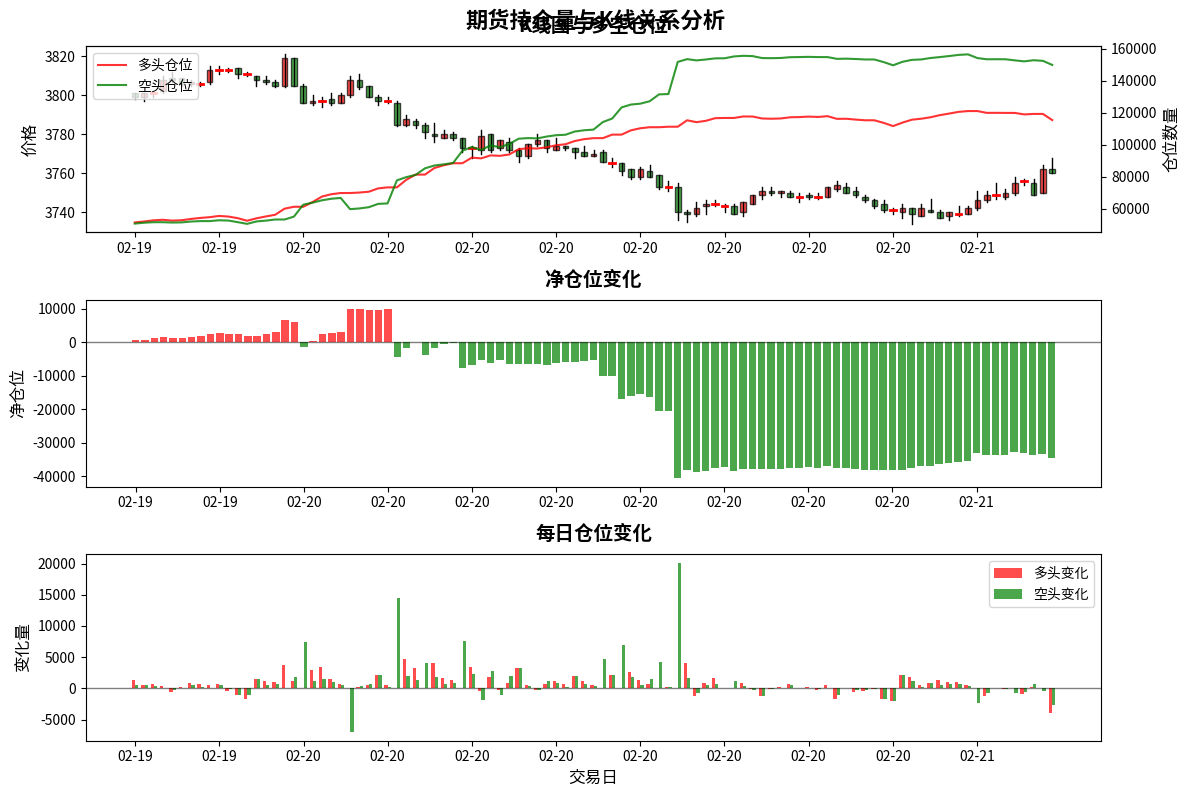


分析结果已保存至: futures_analysis_results.csv


In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
from matplotlib.patches import Rectangle

# 设置中文字体和样式
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False


class FuturesPositionAnalyzer:
    def __init__(self, initial_long=50000, initial_short=50000):
        self.cum_long = initial_long
        self.cum_short = initial_short
        self.position_history = []
        
    def allocate_position_delta(self, price_change, oi_delta, volume_status, prev_long, prev_short):
        """
        完整实现10个规则的仓位分配
        """
        # 规则1: 价涨仓增，成交量放大 → 100% 多头开仓
        if price_change == 1 and oi_delta > 0 and volume_status == 1:
            return oi_delta, 0
            
        # 规则2: 价涨仓增，成交量正常 → 70% 多头开仓，30% 空头开仓
        elif price_change == 1 and oi_delta > 0 and volume_status == 0:
            return int(oi_delta * 0.7), int(oi_delta * 0.3)
            
        # 规则3: 价涨仓增，成交量缩小 → 60% 多头开仓，40% 空头开仓
        elif price_change == 1 and oi_delta > 0 and volume_status == -1:
            return int(oi_delta * 0.6), int(oi_delta * 0.4)
            
        # 规则4: 价涨仓减，成交量放大 → 100% 空头平仓
        elif price_change == 1 and oi_delta < 0 and volume_status == 1:
            return 0, oi_delta  # oi_delta为负值
            
        # 规则5: 价涨仓减，成交量正常 → 80% 空头平仓，20% 多头平仓
        elif price_change == 1 and oi_delta < 0 and volume_status == 0:
            return int(oi_delta * 0.2), int(oi_delta * 0.8)
            
        # 规则6: 价涨仓减，成交量缩小 → 90% 空头平仓，10% 多头平仓
        elif price_change == 1 and oi_delta < 0 and volume_status == -1:
            return int(oi_delta * 0.1), int(oi_delta * 0.9)
            
        # 规则7: 价跌仓增，成交量放大 → 100% 空头开仓
        elif price_change == -1 and oi_delta > 0 and volume_status == 1:
            return 0, oi_delta
            
        # 规则8: 价跌仓增，成交量正常 → 70% 空头开仓，30% 多头开仓
        elif price_change == -1 and oi_delta > 0 and volume_status == 0:
            return int(oi_delta * 0.3), int(oi_delta * 0.7)
            
        # 规则9: 价跌仓增，成交量缩小 → 60% 空头开仓，40% 多头开仓
        elif price_change == -1 and oi_delta > 0 and volume_status == -1:
            return int(oi_delta * 0.4), int(oi_delta * 0.6)
            
        # 规则10: 价跌仓减，成交量放大 → 100% 多头平仓
        elif price_change == -1 and oi_delta < 0 and volume_status == 1:
            return oi_delta, 0  # oi_delta为负值
            
        # 规则11: 价跌仓减，成交量正常 → 80% 多头平仓，20% 空头平仓
        elif price_change == -1 and oi_delta < 0 and volume_status == 0:
            return int(oi_delta * 0.8), int(oi_delta * 0.2)
            
        # 规则12: 价跌仓减，成交量缩小 → 90% 多头平仓，10% 空头平仓
        elif price_change == -1 and oi_delta < 0 and volume_status == -1:
            return int(oi_delta * 0.9), int(oi_delta * 0.1)
            
        # 横盘情况
        elif price_change == 0:
            if oi_delta > 0:  # 仓增
                # 规则13: 横盘仓增，成交量放大 → 50% 多头开仓，50% 空头开仓
                if volume_status == 1:
                    return int(oi_delta * 0.5), int(oi_delta * 0.5)
                # 规则14: 横盘仓增，成交量正常 → 60% 多头开仓，40% 空头开仓
                elif volume_status == 0:
                    return int(oi_delta * 0.6), int(oi_delta * 0.4)
                # 规则15: 横盘仓增，成交量缩小 → 70% 多头开仓，30% 空头开仓
                else:
                    return int(oi_delta * 0.7), int(oi_delta * 0.3)
            else:  # 仓减
                # 规则16: 横盘仓减，成交量放大 → 50% 多头平仓，50% 空头平仓
                if volume_status == 1:
                    return int(oi_delta * 0.5), int(oi_delta * 0.5)
                # 规则17: 横盘仓减，成交量正常 → 60% 多头平仓，40% 空头平仓
                elif volume_status == 0:
                    return int(oi_delta * 0.6), int(oi_delta * 0.4)
                # 规则18: 横盘仓减，成交量缩小 → 70% 多头平仓，30% 空头平仓
                else:
                    return int(oi_delta * 0.7), int(oi_delta * 0.3)
        
        return 0, 0
    
    def _get_price_change(self, current_close, prev_close):
        """判断价格变化方向"""
        if prev_close == 0:
            return 0
        change_pct = (current_close - prev_close) / prev_close
        if abs(change_pct) < 0.001:  # 小于0.1%视为横盘
            return 0
        return 1 if change_pct > 0 else -1
    
    def _get_volume_status(self, current_volume, prev_volume):
        """判断成交量状态"""
        if prev_volume == 0:
            return 0
        volume_ratio = current_volume / prev_volume
        if volume_ratio > 1.3:  # 成交量放大30%以上
            return 1
        elif volume_ratio < 0.7:  # 成交量缩小30%以上
            return -1
        else:
            return 0
    
    def analyze_data(self, data):
        """
        分析整个数据集
        data: DataFrame，包含日期、收盘价、持仓量、成交量
        """
        print("开始分析期货数据...")
        
        for i in range(1, len(data)):
            prev_row = data.iloc[i-1]
            curr_row = data.iloc[i]
            
            # 计算变化量
            price_change = self._get_price_change(curr_row['close'], prev_row['close'])
            oi_delta = curr_row['open_interest'] - prev_row['open_interest']
            volume_status = self._get_volume_status(curr_row['volume'], prev_row['volume'])
            
            # 分配仓位变化
            long_delta, short_delta = self.allocate_position_delta(
                price_change, oi_delta, volume_status, self.cum_long, self.cum_short)
            
            # 更新累积仓位
            self.cum_long += long_delta
            self.cum_short += short_delta
            
            # 记录历史
            record = {
                'date': curr_row.name,
                'close': curr_row['close'],
                'open': curr_row['open'],
                'high': curr_row['high'],
                'low': curr_row['low'],
                'open_interest': curr_row['open_interest'],
                'volume': curr_row['volume'],
                'long_position': self.cum_long,
                'short_position': self.cum_short,
                'net_position': self.cum_long - self.cum_short,
                'long_delta': long_delta,
                'short_delta': short_delta,
                'price_change': price_change,
                'volume_status': volume_status,
                'rule_applied': self._get_rule_description(price_change, oi_delta, volume_status)
            }
            self.position_history.append(record)
        
        print(f"分析完成！共处理 {len(self.position_history)} 个数据点")
        return pd.DataFrame(self.position_history)
    
    def _get_rule_description(self, price_change, oi_delta, volume_status):
        """获取应用的规则描述"""
        volume_desc = {1: "放量", 0: "平量", -1: "缩量"}
        price_desc = {1: "价涨", -1: "价跌", 0: "横盘"}
        oi_desc = "仓增" if oi_delta > 0 else "仓减"
        
        return f"{price_desc[price_change]}{oi_desc}{volume_desc[volume_status]}"
    
    def plot_candlestick(self, ax, df, width=0.6):
        """绘制K线图"""
        # 使用索引作为x轴
        x_values = range(len(df))
        
        # 绘制K线
        for i, (idx, row) in enumerate(df.iterrows()):
            open_price = row['open']
            close_price = row['close']
            high_price = row['high']
            low_price = row['low']
            
            # 确定颜色：上涨为红色，下跌为绿色
            color = 'red' if close_price >= open_price else 'green'
            
            # 绘制影线（最高到最低）
            ax.plot([i, i], [low_price, high_price], color='black', linewidth=1)
            
            # 绘制实体
            body_bottom = min(open_price, close_price)
            body_top = max(open_price, close_price)
            body_height = body_top - body_bottom
            
            # 如果实体高度为0，绘制一条横线
            if body_height == 0:
                ax.plot([i - width/2, i + width/2], [open_price, open_price], color=color, linewidth=2)
            else:
                rect = Rectangle((i - width/2, body_bottom), width, body_height, 
                               facecolor=color, alpha=0.7, edgecolor='black')
                ax.add_patch(rect)

    def plot_comprehensive_analysis(self, df):
        """绘制综合分析图表 - 1列3行纵向排列，去除非交易空白，使用K线图"""
        # 使用索引作为x轴，避免日期不连续造成的空白
        x_values = range(len(df))
        
        fig, axes = plt.subplots(3, 1, figsize=(12, 8))
        
        # 1. K线图与仓位叠加图
        ax1 = axes[0]
        
        # 绘制K线图
        self.plot_candlestick(ax1, df)
        
        # 设置Y轴标签和标题
        ax1.set_ylabel('价格', fontsize=12)
        ax1.set_title('K线图与多空仓位', fontsize=14, fontweight='bold', pad=10)
        
        # 仓位线（右侧Y轴）
        ax1_r = ax1.twinx()
        ax1_r.plot(x_values, df['long_position'], 'r-', alpha=0.8, label='多头仓位', linewidth=1.5)
        ax1_r.plot(x_values, df['short_position'], 'g-', alpha=0.8, label='空头仓位', linewidth=1.5)
        ax1_r.set_ylabel('仓位数量', fontsize=12)
        ax1_r.legend(loc='upper left')
        
        # 2. 净仓位变化
        ax2 = axes[1]
        net_pos = df['net_position']
        colors = ['red' if x > 0 else 'green' for x in net_pos]
        ax2.bar(x_values, net_pos, color=colors, alpha=0.7, width=0.8)
        ax2.axhline(y=0, color='black', linestyle='-', alpha=0.5, linewidth=1)
        ax2.set_title('净仓位变化', fontsize=14, fontweight='bold', pad=10)
        ax2.set_ylabel('净仓位', fontsize=12)
        
        # 3. 每日变化柱状图
        ax3 = axes[2]
        width = 0.35
        ax3.bar([i - width/2 for i in x_values], df['long_delta'], width, 
                label='多头变化', color='red', alpha=0.7)
        ax3.bar([i + width/2 for i in x_values], df['short_delta'], width, 
                label='空头变化', color='green', alpha=0.7)
        ax3.axhline(y=0, color='black', linestyle='-', alpha=0.5, linewidth=1)
        ax3.set_title('每日仓位变化', fontsize=14, fontweight='bold', pad=10)
        ax3.set_ylabel('变化量', fontsize=12)
        ax3.set_xlabel('交易日', fontsize=12)
        ax3.legend()
        
        # 设置X轴刻度标签为实际日期（每隔一定点显示一个日期）
        tick_interval = max(1, len(df) // 10)  # 大约显示10个刻度
        tick_positions = range(0, len(df), tick_interval)
        tick_labels = [df['date'].iloc[i].strftime('%m-%d') for i in tick_positions]
        
        for ax in axes:
            ax.set_xticks(tick_positions)
            ax.set_xticklabels(tick_labels)
        
        plt.tight_layout()
        fig.suptitle('期货持仓量与K线关系分析', fontsize=16, fontweight='bold', y=0.99)
        
        return fig

    def generate_summary_report(self, df):
        """生成分析总结报告"""
        latest = df.iloc[-1]
        prev_day = df.iloc[-2] if len(df) > 1 else latest
        
        print("\n" + "="*60)
        print("期货仓位分析总结报告")
        print("="*60)
        print(f"分析日期: {latest['date'].strftime('%Y-%m-%d')}")
        print(f"最新收盘价: {latest['close']:,.2f}")
        print(f"持仓量: {latest['open_interest']:,.0f}")
        print(f"成交量: {latest['volume']:,.0f}")
        print("\n--- 仓位分析 ---")
        print(f"多头仓位: {latest['long_position']:,.0f} ({latest['long_delta']:+,})")
        print(f"空头仓位: {latest['short_position']:,.0f} ({latest['short_delta']:+,})")
        print(f"净仓位: {latest['net_position']:+,.0f}")
        
        total = latest['long_position'] + latest['short_position']
        long_ratio = (latest['long_position'] / total) * 100
        print(f"多头占比: {long_ratio:.1f}%")
        
        # 市场状态判断
        if latest['net_position'] > 0 and latest['close'] > prev_day['close']:
            status = "🔴 强势多头市场"
        elif latest['net_position'] < 0 and latest['close'] < prev_day['close']:
            status = "🟢 强势空头市场"
        elif latest['net_position'] > 0 and latest['close'] < prev_day['close']:
            status = "🟡 多头抵抗"
        elif latest['net_position'] < 0 and latest['close'] > prev_day['close']:
            status = "🟠 空头抵抗"
        else:
            status = "⚪ 平衡市场"
            
        print(f"\n市场状态: {status}")
        print("="*60)


def main_m(code, date):
    """主函数"""
    print("期货持仓量、成交量与价格关系分析系统")

    # 使用您提供的 get_price_future 函数获取数据
    df = get_price_future(
        symbol_list=code,
        end_date=date,
        start_date=None,
        fre_step='5m',
        fields=['open','high','low','close','volume', 'open_interest'],
        fq='pre',
        bar_count=100
    ).sort_index()
   
    # 初始化分析器
    analyzer = FuturesPositionAnalyzer(initial_long=50000, initial_short=50000)
    
    # 分析数据
    result_df = analyzer.analyze_data(df)
    
    # 生成总结报告
    analyzer.generate_summary_report(result_df)
    
    # 绘制综合图表
    print("\n正在生成分析图表...")
    fig = analyzer.plot_comprehensive_analysis(result_df)
    
    # 保存图表
    fig.savefig('futures_core_analysis.png', dpi=300, bbox_inches='tight')
    
    print("\n图表已保存: futures_core_analysis.png")
    
    # 显示图表
    plt.show()
    
    # 保存分析结果到CSV
    result_df.to_csv('futures_analysis_results.csv', index=False, encoding='utf-8-sig')
    print("\n分析结果已保存至: futures_analysis_results.csv")


if __name__ == "__main__":
    main_m('RB2405','20240221 10:40')